In [203]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mne
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parent
print(dir)

if dir not in sys.path:
    sys.path.append(str(dir))  


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
D:\henry\research\final_thesis\source


### Data Extraction

In [204]:
dens_dir = dir / "data" / "DENS"
gameemo_dir = dir / "data" / "GAMEEMO"

dens_subdirs = [p for p in dens_dir.iterdir() if p.is_dir()]
gameemo_subdirs = [p for p in dens_dir.iterdir() if p.is_dir()]

# remove .datalad and gameplay folders
del dens_subdirs[0]
del gameemo_subdirs[-1]

dens_subj_003_path = dens_subdirs[0] / "eeg" / "sub-mit003_task-Emotion_eeg.set"

In [205]:
# trial subject data extraction
raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)

Reading D:\henry\research\final_thesis\source\data\DENS\sub-mit003\eeg\sub-mit003_task-Emotion_eeg.fdt
Reading 0 ... 674089  =      0.000 ...  2696.356 secs...


C:\Users\User\AppData\Local\Temp\ipykernel_21756\2283471359.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
pns: ['ECG', 'EMG', 'EMG_2']
  raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)
C:\Users\User\AppData\Local\Temp\ipykernel_21756\2283471359.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)


In [206]:
raw_003_dens.ch_names[-10:]

['E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129', 'ECG', 'EMG', 'EMG_2']

In [207]:
# based the metadata description in the JSON, the montage type follows GSN-HydroCel-129 settings
raw_003_dens.set_channel_types({"ECG" : "ecg", "EMG" : "emg", "EMG_2" : "emg"})
raw_003_dens.rename_channels({"E129": "Cz"})

raw_003_dens.set_montage(mne.channels.make_standard_montage("GSN-HydroCel-129"), match_case=False)
raw_003_dens.info

<Info | 8 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 EEG, 1 ECG, 2 EMG
 custom_ref_applied: False
 dig: 132 items (3 Cardinal, 129 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 132
 projs: []
 sfreq: 250.0 Hz
>

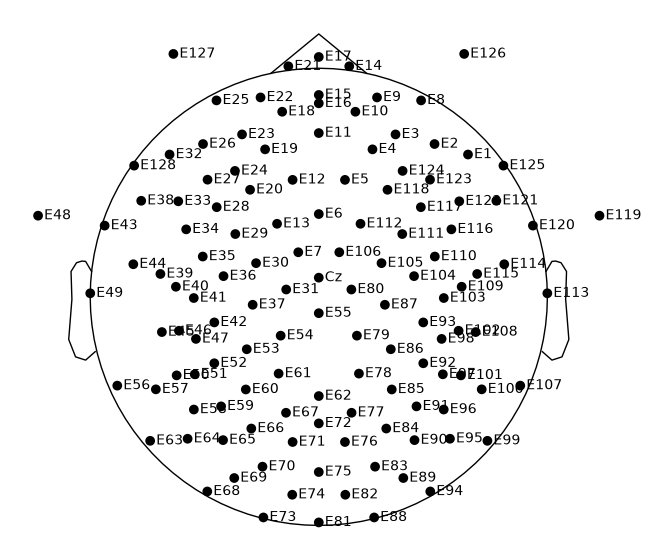

Figure(640x640)


In [208]:
# visualize the EEG placements
print(raw_003_dens.plot_sensors(show_names=True))

### Basic Preprocessing & Filtering

In [209]:
dens_003 = raw_003_dens.copy()

# # re-referencing using average of all electrodes
dens_003 = dens_003.set_eeg_reference(ref_channels="average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


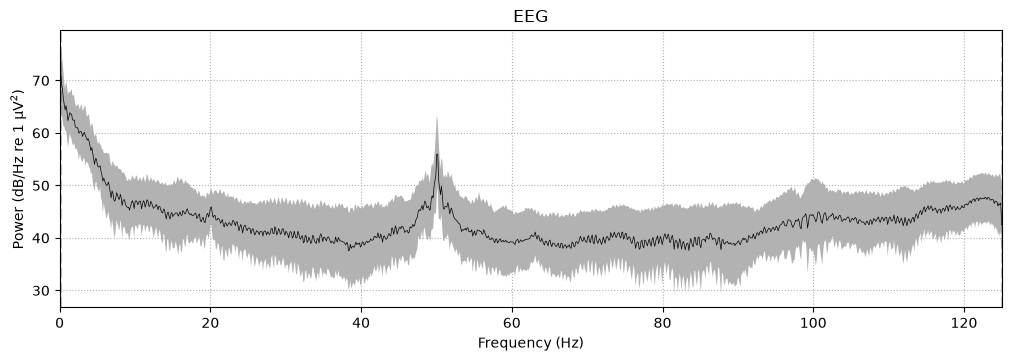

In [210]:
# since the DENS dataset contains other than EEG channels, we could assume there are other noise or artifacts contained
# in the raw EEG signal

# therefore, we need to handle these artifacts, power-line, noises.
fig = dens_003.compute_psd(tmax=np.inf, fmax=125).plot(
  average=True, amplitude=False, picks="data", exclude="bads"
)

# add some arrows at 60 Hz and its harmonics:
for ax in fig.axes[1:]:
    freqs = ax.lines[-1].get_xdata()
    psds = ax.lines[-1].get_ydata()
    for freq in (60, 120, 180, 240):
        idx = np.searchsorted(freqs, freq)
        ax.arrow(
            x=freqs[idx],
            y=psds[idx] + 18,
            dx=0,
            dy=-12,
            color="red",
            width=0.1,
            head_width=3,
            length_includes_head=True,
        )

#### Note 

From the plot, we can see there is a spike in the 40-60 Hz range. It's strongly suggest the presence of a power line artifact activity sitting in the 50Hz freq just as the metadata describes.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoffs at 1.00, 40.00 Hz: -6.02, -6.02 dB



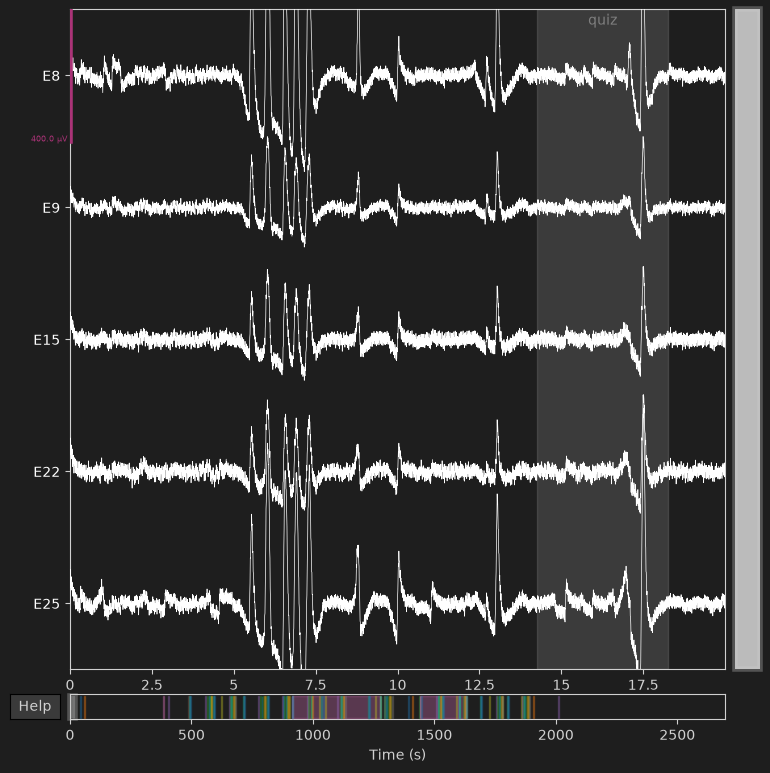

Figure(800x800)


In [211]:
# apply butterworth filtering with order 2 with band between 1 Hz and 40 Hz (standard treatment)
# this would isolate frequency regions that we are interested
iir_params = dict(order=2, ftype='butter')
dens_003.filter(l_freq=1.0, h_freq=40.0, method='iir', iir_params=iir_params, verbose=True)

# analyze the electrodes on frontal lobe area
channels = ["E25", "E22", "E15", "E9", "E8"]

print(dens_003.plot(
  duration=20,
  n_channels=len(channels),
  picks=channels,
  scalings=dict(eeg=200e-6),  
  clipping=1.5                 
))

#### Note

The spikes observed in the plot strongly suggest the presence of physiological artifacts, such as eye blinks, muscle movements, and cardiac activity.

In [212]:
# no bad channels available
dens_003.info["bads"]

[]

#### Artifact & Noise Removal Using ICA